In [1]:
import torch
import numpy as np
from network import ScoreNetwork
import matplotlib.pyplot as plt
from utils import rollout

In [2]:
T = 4.0  # End time
n = 2    # Dimension of state space
m = 1    # Dimension of Brownian motion
N = 10000 # Number of training samples
dt = 0.05
steps = int(T/dt)
noise_level = 0.5

In [3]:
def f(x, t, ut=None):
    """
    Drift function of X_t for a nonlinear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Drift vector. Shape (N, n)
    """
    df1 = x[:, 1]
    df2 = torch.sin(x[:, 0]) - 0.01 * x[:, 1]
    df = torch.stack((df1, df2), dim=1)
    return df


def g(x):
    """
    Diffusion function of X_t for a nonlinear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Diffusion matrix. Shape (N, n, m)
    """
    B = torch.tensor([[0.0], [1.0]]) * noise_level
    B = B.unsqueeze(0).repeat(x.shape[0], 1, 1)
    return B

def lf(x):
    """
    Terminal cost function for a linear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Terminal cost. Shape (N,)
    """
    # Q_f = torch.tensor([[1.0, 0.0], [0.0, 1.0]])
    # return 0.5 * ((x @ Q_f) * x).sum(dim=1)
    return 0.5 * x[:,1] * x[:,1] + 1 - torch.cos(x[:,0])

In [4]:
# theta_hist_phi = torch.load('data/theta_hist_phi_nl0.5_v3.pt')
# theta_hist_auto = torch.load('data/theta_hist_auto_nl0.5_v3.pt')

In [5]:
theta_phi_final = torch.load('data/theta_tr_final.pth')
theta_auto_final = torch.load('data/theta_ad_final.pth')
# theta_auto_final = theta_hist_auto[-1,:,:]

/var/folders/pd/hp6m3j2j5v9bd6w64h7wl3rm0000gn/T/ipykernel_51764/2425831529.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  theta_phi_final = torch.load('data/theta_tr_f

(-2.0, 2.0)

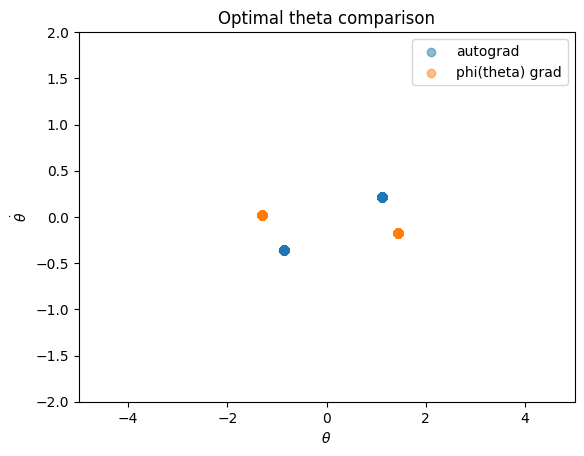

In [ ]:
plt.figure()
plt.scatter(theta_auto_final[:,0].detach().numpy(), theta_auto_final[:,1].detach().numpy(), label="autograd", alpha=0.5)
plt.scatter(theta_phi_final[:,0].detach().numpy(), theta_phi_final[:,1].detach().numpy(), label="phi(theta) grad", alpha=0.5)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\dot{\theta}$")
plt.legend()
plt.title("Optimal theta comparison")
plt.xlim([-5,5])
plt.ylim([-2,2])

In [7]:
nx, ny = 200, 80
# create a grid of points

x = torch.linspace(-5.0, 5.0, nx)
y = torch.linspace(-2.0, 2.0, ny)

# meshgrid
X, Y = torch.meshgrid(x, y, indexing='ij')  # shapes (nx, ny)

In [8]:
theta_grid = torch.stack((X, Y), dim=2).reshape(-1, 2)  # shape (nx*ny, 2)

In [ ]:
exp_num = 10000
loss_vec = torch.zeros((theta_grid.shape[0], 1))
for exp_i in range(exp_num):
    
    W_f = torch.randn(steps + 1, theta_grid.shape[0], m) * torch.sqrt(torch.tensor(dt))
    
    loss_vec += lf(rollout(f, g, T, dt, theta_grid, W_f)[-1]).unsqueeze(-1) # shape (N, 1)
    

    if exp_i % 100 == 0:
        print(f"experiment {exp_i}/{exp_num} done.")

loss_vec /= exp_num  # shape (N, 1)

experiment 0/10000 done.
experiment 100/10000 done.
experiment 200/10000 done.
experiment 300/10000 done.
experiment 400/10000 done.
experiment 500/10000 done.
experiment 600/10000 done.
experiment 700/10000 done.
experiment 800/10000 done.
experiment 900/10000 done.
experiment 1000/10000 done.
experiment 1100/10000 done.
experiment 1200/10000 done.
experiment 1300/10000 done.
experiment 1400/10000 done.
experiment 1500/10000 done.
experiment 1600/10000 done.
experiment 1700/10000 done.
experiment 1800/10000 done.
experiment 1900/10000 done.
experiment 2000/10000 done.
experiment 2100/10000 done.
experiment 2200/10000 done.
experiment 2300/10000 done.
experiment 2400/10000 done.
experiment 2500/10000 done.
experiment 2600/10000 done.
experiment 2700/10000 done.
experiment 2800/10000 done.
experiment 2900/10000 done.
experiment 3000/10000 done.
experiment 3100/10000 done.
experiment 3200/10000 done.
experiment 3300/10000 done.
experiment 3400/10000 done.
experiment 3500/10000 done.
expe

In [10]:
loss_grid = loss_vec.reshape(nx,ny)

In [ ]:
loss_grid = torch.load('data/loss_grid_nl0.5.pth', weights_only=True)
# theta_auto = torch.load('data/theta_hist_auto_nl0.5_v3.pt', weights_only=True)
# theta_phi = torch.load('data/theta_hist_phi_nl0.5_v3.pt', weights_only=True)
theta_ad = torch.load('data/theta_ad_final.pth', weights_only=True)
theta_phi = torch.load('data/theta_tr_final.pth', weights_only=True)

In [ ]:
# theta_auto_final = theta_auto[-1,:,:]
# theta_phi_final = theta_phi[-1,:,:]

In [26]:
import matplotlib

plt.rc('font', size = 14)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

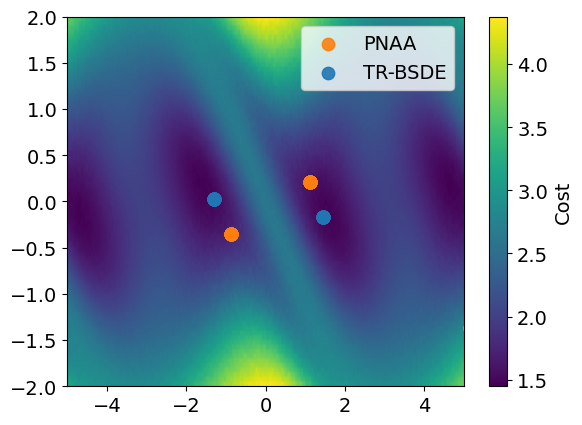

In [27]:
plt.figure()
im = plt.imshow(
    loss_grid.T,                         # transpose for correct orientation
    extent=[-5, 5, -2, 2],
    origin='lower',
    aspect='auto',
    cmap='viridis'
)
# plt.scatter(theta_auto_final[:,0].detach().numpy(), theta_auto_final[:,1].detach().numpy(), label="AutoDiff", alpha=0.5, color='C1')
plt.scatter(theta_ad[:,0].detach().numpy(), theta_ad[:,1].detach().numpy(), label="PNAA", alpha=0.9, color='C1', s=80)
plt.scatter(theta_phi[:,0].detach().numpy(), theta_phi[:,1].detach().numpy(), label="TR-BSDE", alpha=0.9, color='C0', s=80)
plt.colorbar(im, label='Cost')
# plt.xlabel(r'$\theta$')
# plt.ylabel(r'$\dot{\theta}$')
plt.legend()
plt.xlim([-5,5])
plt.ylim([-2,2])
# plt.title('Heatmap of f(x, y)')
# plt.show()
plt.savefig("figs/IP_optresult_vs_heatmap_pnaa.png", bbox_inches='tight')
